In [1]:
pip install medmnist

  Using cached medmnist-3.0.2-py3-none-any.whl.metadata (14 kB)
  Using cached scikit_image-0.26.0-cp312-cp312-win_amd64.whl.metadata (15 kB)
  Using cached fire-0.7.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached torchvision-0.28.0-cp312-cp312-win_amd64.whl.metadata (5.6 kB)
Using cached medmnist-3.0.2-py3-none-any.whl (25 kB)
Using cached fire-0.7.1-py3-none-any.whl (115 kB)
Using cached scikit_image-0.26.0-cp312-cp312-win_amd64.whl (11.9 MB)
Using cached torchvision-0.28.0-cp312-cp312-win_amd64.whl (4.1 MB)

   ---------------------------------------- 0/4 [fire]
   ---------------------------------------- 0/4 [fire]
   ---------------------------------------- 0/4 [fire]
   ---------------------------------------- 0/4 [fire]
   ---------------------------------------- 0/4 [fire]
   ---------------------------------------- 0/4 [fire]
   ---------------------------------------- 0/4 [fire]
   ---------------------------------------- 0/4 [fire]
   ---------- -------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from medmnist import PathMNIST

In [4]:
train_dataset = PathMNIST(split = 'train', download = True, size = 224)
print("train loaded")
val_dataset = PathMNIST(split = 'val', download = True, size = 224)
print("val loaded")
test_dataset = PathMNIST(split = 'test', download = True, size = 224)
print("test loaded")

train loaded
val loaded
test loaded


In [6]:
print(train_dataset)

Dataset PathMNIST of size 224 (pathmnist_224)
    Number of datapoints: 89996
    Root location: C:\Users\shriya\.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
    Number of samples: {'train': 89996, 'val': 10004, 'test': 7180}
    Description: The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split 

In [7]:
print(train_dataset.imgs.shape)
print(val_dataset.imgs.shape)
print(test_dataset.imgs.shape)

(89996, 224, 224, 3)
(10004, 224, 224, 3)
(7180, 224, 224, 3)


In [11]:
print(train_dataset.labels.shape)
print(val_dataset.labels.shape)
print(test_dataset.labels.shape)

(89996, 1)
(10004, 1)
(7180, 1)


[4]


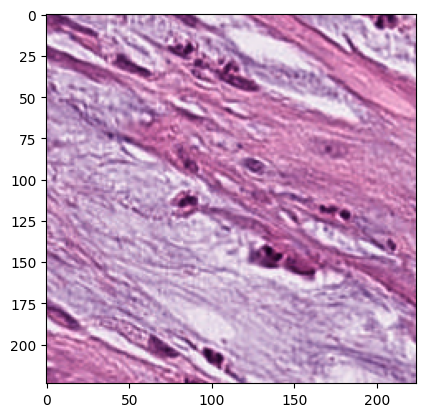

In [14]:
import matplotlib.pyplot as plt

img, label = train_dataset[1]
print(label)
plt.imshow(img)
plt.show()

In [34]:
import pandas as pd

train_series = pd.Series(train_dataset.labels.flatten())
train_series = train_series.sort_values()
print("all the classes: ", train_series.unique())
print("number of unique classes: ", train_series.nunique())
print("class distribution:\n", train_series.value_counts().sort_index())


all the classes:  [0 1 2 3 4 5 6 7 8]
number of unique classes:  9
class distribution:
 0     9366
1     9509
2    10360
3    10401
4     8006
5    12182
6     7886
7     9401
8    12885
Name: count, dtype: int64


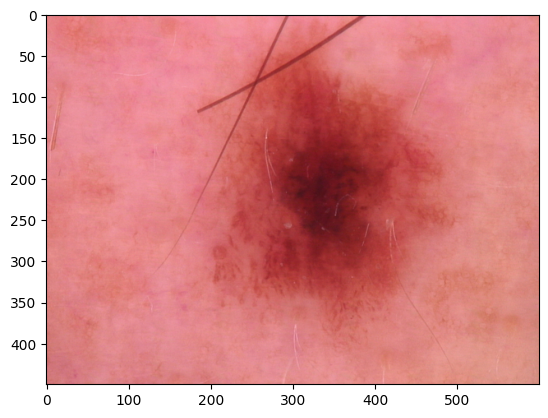

In [49]:
import os
from dotenv import load_dotenv
import matplotlib.image as mpimg

load_dotenv(dotenv_path='../.env')
image_path = os.environ.get('ISIC_IMAGE_PATH')
img = mpimg.imread(image_path)
plt.imshow(img)
plt.show()